In [74]:
import pandas as pd
from sklearn.metrics import confusion_matrix

In [3]:
df=pd.read_csv('AirQualityodisha.csv')

In [4]:
df.head()

,Stn Code,Sampling Date,State,City,Location of Monitoring Station,Agency,Type of Location,SO2,NO2,RSPM/PM10,PM 2.5
0,68,02-01-15,Odisha,Talcher,"T.T.P.S.Colony, Talcher",Odisha State Pollution Control Board,Industrial Area,11,24,143,102.0
1,68,06-01-15,Odisha,Talcher,"T.T.P.S.Colony, Talcher",Odisha State Pollution Control Board,Industrial Area,10,23,133,96.0
2,68,09-01-15,Odisha,Talcher,"T.T.P.S.Colony, Talcher",Odisha State Pollution Control Board,Industrial Area,8,25,125,116.0
3,68,13-01-15,Odisha,Talcher,"T.T.P.S.Colony, Talcher",Odisha State Pollution Control Board,Industrial Area,10,25,137,107.0
4,68,16-01-15,Odisha,Talcher,"T.T.P.S.Colony, Talcher",Odisha State Pollution Control Board,Industrial Area,9,26,186,118.0


In [5]:
df.isnull().sum()

Stn Code                            0
Sampling Date                       0
State                               0
City                                0
Location of Monitoring Station      0
Agency                              0
Type of Location                    0
SO2                                 0
NO2                                 0
RSPM/PM10                           0
PM 2.5                            332
dtype: int64

In [6]:
df['PM 2.5']

0       102.0
1        96.0
2       116.0
3       107.0
4       118.0
        ...  
2387     35.0
2388     40.0
2389     38.0
2390     39.0
2391     39.0
Name: PM 2.5, Length: 2392, dtype: float64

In [7]:
mean=df['PM 2.5'].mean()
mean

42.47281553398058

In [10]:
df['PM 2.5']=df['PM 2.5'].fillna(mean)

In [11]:
df.isnull().sum()

Stn Code                          0
Sampling Date                     0
State                             0
City                              0
Location of Monitoring Station    0
Agency                            0
Type of Location                  0
SO2                               0
NO2                               0
RSPM/PM10                         0
PM 2.5                            0
dtype: int64

In [12]:
import seaborn as sns

<AxesSubplot:>

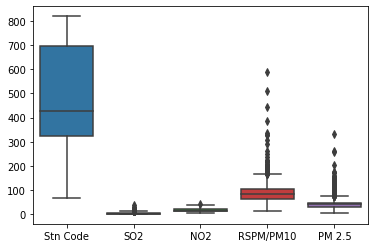

In [14]:
sns.boxplot(data=df)

In [22]:
# Q1 25% of data
# Q3 is 75% of data

# Q3-Q1 is interquartal range

In [17]:
# upper= Q3+1.5*(Q3-Q1)
# lower= Q1-1.5*(Q3-Q1)

In [18]:
import numpy as np

In [20]:
Q1=np.percentile(df['RSPM/PM10'],25)

In [21]:
Q3=np.percentile(df['RSPM/PM10'],75)

In [24]:
range=Q3-Q1
range

42.0

In [25]:
upper=Q3+1.5*(Q3-Q1)
upper

168.0

In [26]:
lower= Q1-1.5*(Q3-Q1)
lower

0.0

In [31]:
df['RSPM/PM10']=df[(df['RSPM/PM10']>lower) & (df['RSPM/PM10']<upper)]

<AxesSubplot:>

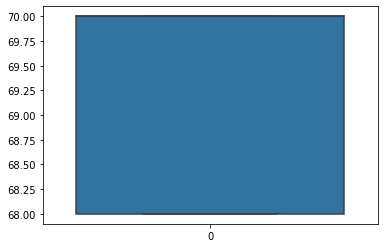

In [35]:
sns.boxplot(data=df['RSPM/PM10'])

# classification model

In [36]:
heart=pd.read_csv('Heart.csv')
heart.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [43]:
from sklearn.linear_model import LogisticRegression

In [62]:
x=heart[['Age']]
y=heart[['Sex']]

In [63]:
model=LogisticRegression()

In [64]:
model.fit(x,y)

C:\Users\Ashu\.conda\envs\arthenv\lib\site-packages\sklearn\utils\validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


LogisticRegression()

In [65]:
model.predict([[2266]])

array([0], dtype=int64)

AttributeError: 'LogisticRegression' object has no attribute 'history'

In [75]:
# Classification model 

In [76]:
heart.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [77]:
from sklearn.model_selection import train_test_split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [80]:
new_model=LogisticRegression()

In [81]:
new_model.fit(X_train,y_train)

C:\Users\Ashu\.conda\envs\arthenv\lib\site-packages\sklearn\utils\validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


LogisticRegression()

In [86]:
new_model.predict([[1000]])

array([0], dtype=int64)

In [88]:
y_pred=new_model.predict(X_test)

In [89]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

In [90]:
confusion_matrix(y_test,y_pred)

array([[ 0, 27],
       [ 0, 73]], dtype=int64)